In [223]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv


load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [224]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData,ForeignKey,Float
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别
from faker import Faker
import random
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,ToolMessage

# 创建基类
Base = declarative_base()

class SalesData(Base):
    __tablename__ = 'sales_data'
    sales_id = Column(Integer, primary_key=True)
    product_id= Column(Integer,ForeignKey('product_information.product_id'))
    employee_id=Column(Integer)
    customer_id=Column(Integer,ForeignKey('customer_information.customer_id'))
    sale_date=Column(String(50))
    quantity=Column(Integer)
    amount=Column(Float)
    discount=Column(Float)
    
class CustomerInformation(Base):
    __tablename__ = 'customer_information'
    customer_id=Column(Integer,primary_key=True)
    customer_name=Column(String(50))
    contact_info=Column(String(50))
    region=Column(String(50))
    customer_type=Column(String(50))
    
class ProductInformation(Base):
    __tablename__ = 'product_information'
    product_id=Column(Integer,primary_key=True)
    product_name=Column(String(50))
    category=Column(String(50))
    unit_price=Column(Float)
    stock_level=Column(Integer)
    
class CompetitorAnalysis(Base):
    __tablename__ = 'competitor_analysis'
    competitor_id=Column(Integer,primary_key=True)
    competitor_name=Column(String(50))
    region=Column(String(50))
    market_share=Column(Float)
    

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)
Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-06-26 13:59:21,511 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-06-26 13:59:21,512 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-26 13:59:21,555 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-06-26 13:59:21,557 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-26 13:59:21,569 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-06-26 13:59:21,570 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-26 13:59:21,579 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-26 13:59:21,604 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`sales_data`
2026-06-26 13:59:21,607 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-26 13:59:21,621 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`customer_information`
2026-06-26 13:59:21,623 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-26 13:59:21,626 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`product_information`
2026-06-26 13:59:21,627 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-26 13:

In [225]:
from pydantic import BaseModel,Field
from langchain_core.tools import tool
from typing import Union,Optional

class AddSaleSchema(BaseModel):
    product_id:int
    employee_id:int
    customer_id:int
    sale_date:str
    quantity:int
    amount:float
    discount:float
    
class DeleteSaleSchema(BaseModel):
    sales_id:int

class UpdateSaleSchema(BaseModel):
    sales_id:int
    quantity:int
    amount:float

class QuerySalesSchema(BaseModel):
    sales_id:int

@tool(args_schema=AddSaleSchema)
def add_sale(product_id,employee_id,customer_id,sale_date,quantity,amount,discount):
    """Add sale record to the database"""
    session=Session()
    try:
        new_sale=SalesData(
            product_id=product_id,
            employee_id=employee_id,
            customer_id=customer_id,
            sale_date=sale_date,
            quantity=quantity,
            amount=amount,
            discount=discount
        )
        session.add(new_sale)
        session.commit()
        return {"messages":["销售记录添加成功。"]}
    except Exception as e:
        return {"messages":[f"添加失败，错误原因：{e}"]}
    finally:
        session.close()

@tool(args_schema=DeleteSaleSchema)
def delete_sale(sales_id):
    """Delete sale record from the database."""
    session=Session()
    try:
        sale_to_delete=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_delete:
            session.delete(sale_to_delete)
            session.commit()
            return {"messages":["销售记录删除成功。"]}
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"删除失败，错误原因:{e}"]}
    finally:
        session.close()
        
@tool(args_schema=UpdateSaleSchema)
def update_sale(sales_id,quantity,amount):
    """Update sale record in the database"""
    session=Session()
    try:
        sale_to_update=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_update:
            sale_to_update.quantity=quantity
            sale_to_update.amount=amount
            session.commit()
            return {"messages":["销售记录更新成功。"]}
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"更新失败，错误原因:{e}"]}
    finally:
        session.close()

@tool(args_schema=QuerySalesSchema)
def query_sales(sales_id):
    """Query sale record in the database"""
    session=Session()
    try:
        sale_data=session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_data:
            return {
                "sales_id":sale_data.sales_id,
                "product_id":sale_data.product_id,
                "employee_id":sale_data.employee_id,
                "customer_id":sale_data.customer_id,
                "sale_date":sale_data.sale_date,
                "quantity":sale_data.quantity,
                "amount":sale_data.amount,
                "discount":sale_data.discount
            }
        else:
            return {"messages":[f"未找到销售记录ID:{sales_id}"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因:{e}"]}
    finally:
        session.close()

In [226]:
from typing import Annotated
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
import json

repl=PythonREPL()

@tool
def python_repl(
    code:Annotated[str,"The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result=repl.run(code)
    except BaseException as e:
        return f"Failed to execute.Error: {repr(e)}"
    result_str=f"Successfully executed:\n\`\`\` python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

In [227]:
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph,START,END
from langchain.agents import create_agent

In [228]:
db_agent=create_agent(
    llm,
    tools=[add_sale,delete_sale,update_sale,query_sales],
    system_prompt="""You are a database query agent. Your ONLY job is to query 
the database using tools and return the raw data. 
CRITICAL RULES:
- NEVER generate charts, graphs, visualizations, or Mermaid syntax.
- NEVER add analysis, summaries, or conclusions to the data.
- NEVER format data as markdown tables.
- Only use tools to query data. Return the results as-is.
- This is a multi-agent system: another agent (coder) handles all chart generation."""
)

In [229]:
# response=db_agent.invoke({"messages":"帮我查询销售id是5,6，7的数据"})
# response

In [230]:
code_agent=create_agent(
    llm,
    tools=[python_repl],
    system_prompt="""You are a Python code execution agent. Your job is to write 
and execute Python code to generate charts, graphs, and data visualizations.
- Use matplotlib (with Chinese font support) to create bar charts, pie charts, etc.
- Use the python_repl tool to execute your code.
- Extract data values from the conversation history to populate the chart.
- When you see JSON data (with fields like sales_id, amount, quantity), parse it 
  and use it to create the visualization.
- Print a confirmation message when the chart is successfully generated."""
)

In [231]:
# response=db_agent.invoke({"messages":"帮我查询销售id是5,6，7的数据"})
# codeResponse=code_agent.invoke({"messages":["根据messages中的数据生成一个柱状图"]+response["messages"]})
# codeResponse

In [232]:
import operator
from typing import Annotated

from langgraph.graph import StateGraph,MessagesState,START,END

class AgentState(MessagesState):
    next:str
    step_count:Annotated[int,operator.add]

In [233]:
def db_node(state:AgentState):
    # ✅ 只传递 messages，避免将 next/step_count 等状态字段传给子 agent
    result=db_agent.invoke({"messages": state["messages"]})
    # ✅ 提取 ToolMessage（工具返回的原始数据），而不是 Agent 的最终对话回复
    tool_messages = [m for m in result["messages"] if isinstance(m, ToolMessage)]
    if tool_messages:
        # 构建干净的原始数据文本
        data_lines = ["[sqler 查询结果]:"]
        for tm in tool_messages:
            data_lines.append(tm.content)  # tm.content 已经是 JSON 字符串
        data_summary = "\n".join(data_lines)
    else:
        # 如果没有工具调用（例如 Agent 直接回复），使用原始回复
        data_summary = result["messages"][-1].content
    
    return {"messages": [
        HumanMessage(content=data_summary, name="sqler")
    ]}

In [234]:
def code_node(state:AgentState):
    # ✅ 只传递 messages，避免将 next/step_count 等状态字段传给子 agent
    result=code_agent.invoke({"messages": state["messages"]})
    # 提取代码执行相关的消息（优先工具结果，其次AI最终回复）
    tool_messages = [m for m in result["messages"] if isinstance(m, ToolMessage)]
    if tool_messages:
        # 取最后一条工具消息（通常是 Python REPL 的输出）
        final_content = "[coder 图表生成结果]:\n" + tool_messages[-1].content
    else:
        final_content = result["messages"][-1].content
    return {"messages": [
        HumanMessage(content=final_content, name="coder")
    ]}

In [235]:
members=["chat","coder","sqler"]
options=members+["FINISH"]

In [236]:
from typing import Literal
from typing_extensions import TypedDict

class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH"""
    next: Literal["chat", "coder", "sqler", "FINISH"]

In [237]:
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,ToolMessage
MAX_STEPS=10
def supervisor(state:AgentState):
    if state.get("step_count",0) >= MAX_STEPS:
        return {"next":"FINISH"}
    
    system_prompt=(
    "You are a supervisor tasked with managing a conversation between the "
    f"following workers: {members}. \n\n"
    "Each worker has a specific role: \n"
    "- chat: Responds directly to user inputs using natural language.\n"
    "- coder: Activated ONLY when the user explicitly asks for charts, graphs, "
    "  data visualization (柱状图/图表/可视化/绘图), or code execution.\n"
    "- sqler: Used when database queries or SQL operations are needed (查询/添加/删除/更新).\n\n"
    "DECISION LOGIC (check the USER'S ORIGINAL REQUEST):\n"
    "1. Pure data query (查询/添加/删除/更新, no chart request) → sqler → FINISH.\n"
    "2. Pure chart/code request (no data query needed) → coder → FINISH.\n"
    "3. Data query + chart request → sqler → coder → FINISH.\n"
    "4. Simple chat (no data, no code) → chat → FINISH.\n\n"
    "KEY PRINCIPLE: Only route to coder if the USER explicitly asked for "
    "charts/graphs/visualization/图表/柱状图/可视化/绘图. "
    "A data query alone does NOT need coder — finish after sqler returns results.\n\n"
    "Given the conversation history, respond with the worker to act next."
    " When the task is fully complete, respond with FINISH."
)

    
    messages=[{"role":"system","content":system_prompt},]+state["messages"]
    response=llm.with_structured_output(Router,method="function_calling").invoke(messages)
    count=state.get("step_count")
    print(f"step count: {count}, next: {response['next']}")
    return {"next": response['next'],"step_count":1}

In [238]:
def chat(state:AgentState):
    messages=state["messages"][-1]
    model_response=llm.invoke(messages.content)
    final_response=[HumanMessage(content=model_response.content,name="chat")]
    return {"messages":final_response}

In [239]:
builder=StateGraph(AgentState)

builder.add_node("supervisor",supervisor)
builder.add_node("chat",chat)
builder.add_node("coder",code_node)
builder.add_node("sqler",db_node)

for member in members:
    builder.add_edge(member,"supervisor")
    
builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "chat": "chat",
        "coder": "coder",
        "sqler": "sqler",
        "FINISH": END,
    },
)

graph = builder.compile()

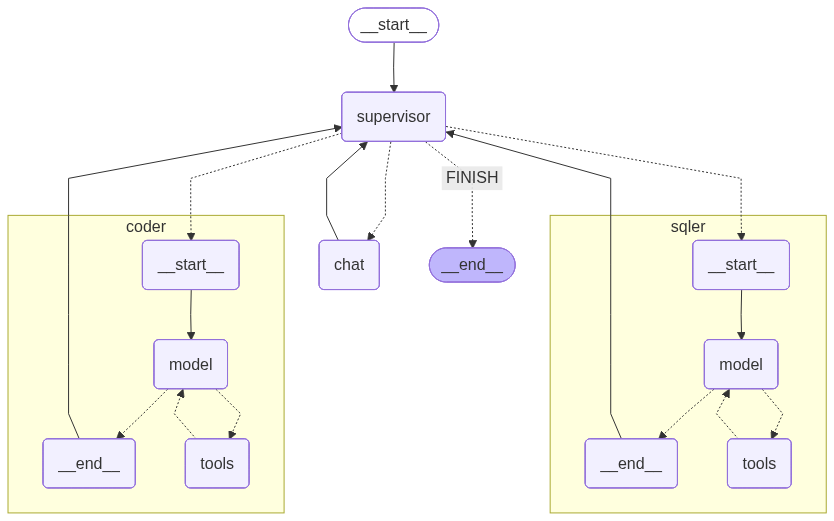

In [240]:
from IPython.display import display,Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
for chunk in graph.stream({"messages":"帮我查询id是5,6,7的销售记录的具体信息"},stream_mode="values"):
    print(chunk)

In [241]:
for chunk in graph.stream({"messages":"帮我根据5,6,7的销售记录id，生成对应的销售额柱状图"},stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='帮我根据5,6,7的销售记录id，生成对应的销售额柱状图', additional_kwargs={}, response_metadata={}, id='db9ee0f7-9e79-458b-9587-1db4a8840ed5')], 'step_count': 0}
step count: 0, next: sqler
{'messages': [HumanMessage(content='帮我根据5,6,7的销售记录id，生成对应的销售额柱状图', additional_kwargs={}, response_metadata={}, id='db9ee0f7-9e79-458b-9587-1db4a8840ed5')], 'next': 'sqler', 'step_count': 1}
2026-06-26 13:59:51,432 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-26 13:59:51,723 INFO sqlalchemy.engine.Engine SELECT sales_data.sales_id AS sales_data_sales_id, sales_data.product_id AS sales_data_product_id, sales_data.employee_id AS sales_data_employee_id, sales_data.customer_id AS sales_data_customer_id, sales_data.sale_date AS sales_data_sale_date, sales_data.quantity AS sales_data_quantity, sales_data.amount AS sales_data_amount, sales_data.discount AS sales_data_discount 
FROM sales_data 
WHERE sales_data.sales_id = %(sales_id_1)s 
 LIMIT %(param_1)s
2026-06-26 13:59:51,792 INFO sql

<string>:29: UserWarning: Glyph 165 (\N{YEN SIGN}) missing from font(s) SimHei.
<string>:30: UserWarning: Glyph 165 (\N{YEN SIGN}) missing from font(s) SimHei.
<string>:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


{'messages': [HumanMessage(content='帮我根据5,6,7的销售记录id，生成对应的销售额柱状图', additional_kwargs={}, response_metadata={}, id='db9ee0f7-9e79-458b-9587-1db4a8840ed5'), HumanMessage(content='[sqler 查询结果]:\n{"sales_id": 5, "product_id": 14, "employee_id": 4, "customer_id": 37, "sale_date": "2025-07-04", "quantity": 5, "amount": 3860.46, "discount": 0.0981342}\n{"sales_id": 6, "product_id": 4, "employee_id": 9, "customer_id": 6, "sale_date": "2025-09-07", "quantity": 4, "amount": 4682.22, "discount": 0.0892105}\n{"sales_id": 7, "product_id": 2, "employee_id": 4, "customer_id": 26, "sale_date": "2025-08-19", "quantity": 2, "amount": 3502.34, "discount": 0.00245959}', additional_kwargs={}, response_metadata={}, name='sqler', id='f5018ecd-b802-4982-9d4f-c67bad3e2c1a'), HumanMessage(content='[coder 图表生成结果]:\nSuccessfully executed:\n\\`\\`\\` python\n\nimport matplotlib.pyplot as plt\nimport matplotlib\nmatplotlib.rcParams[\'font.sans-serif\'] = [\'SimHei\', \'DejaVu Sans\']\nmatplotlib.rcParams[\'axes.uni

In [ ]:
for chunk in graph.stream({"messages":"帮我查询前10名的销售记录id，生成对应的销售额柱状图"},stream_mode="values"):
    print(chunk)

In [ ]:
for chunk in graph.stream({"messages":"帮我生成一个柱状图"},{"recursion_limit":20},stream_mode="values"):
    print(chunk)